# Bayesian ancestral states on a phylogeny

In [notebook 03](03_phylo_mean.ipynb) we used `phylo_mean` to get *point estimates* of ancestral states — every internal node was assigned a single number, with no notion of uncertainty. That answers "what's the most plausible state?" but ignores "how sure are we?"

This notebook upgrades that point estimate to a **full Bayesian inference**: under a Gaussian generative model, we obtain the *exact posterior distribution* over every internal node, with calibrated credible intervals. Where phylo_mean returned one value per ancestor, here we get a whole distribution.

The closed-form smoothing algorithm that delivers this posterior is the Gaussian case of **Backward Filtering Forward Guiding (BFFG)** as formulated in

> van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* Journal of Machine Learning Research, Vol. 26, Art. 281, pp. 1–51. ([arXiv:2505.18239](https://arxiv.org/abs/2505.18239))

BFFG really earns its keep further on, when transitions stop being linear-Gaussian and we want to infer **hyperparameters** as well as states — see [notebook 05](05_gaussian_bffg.ipynb) (MCMC on the Gaussian model), [notebook 06](06_gaussian_nuts.ipynb) (differentiability + NUTS via numpyro), and [notebook 07](07_kunita_shape.ipynb) (full SDE bridges). In *this* notebook the hyperparameters $(\sigma^2, \tau^2)$ are **known**, and we use BFFG purely as the closed-form smoother that turns leaf observations into per-node Gaussian posteriors. That keeps the focus on the Bayesian framing.

What you will see:

1. State the linear-Gaussian tree model in the paper's notation.
2. **Forward-simulate** ground-truth states at every node by sampling from the prior, and noise the leaves to produce observations.
3. Run the **backward filter** (`gaussian_up`) to summarize the leaf evidence as a canonical Gaussian message $h_v(x) = \exp(c_v - \tfrac12 x^\top H_v x + F_v^\top x)$ at every node.
4. Run the **forward guide** (`gaussian_down_conditional`) many times to draw independent posterior samples at every internal node.
5. Compare the BFFG posterior to the `phylo_mean` point estimate from notebook 03, and verify calibration against the simulated ground truth.

We reuse the small primate tree from notebook 03 so the comparison is direct.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx
from hyperiax.io import newick
from hyperiax.prebuilt import (
    gaussian_up,
    gaussian_down_conditional,
    gaussian_down_unconditional,
    init_gaussian_leaves,
    phylo_mean,
)

PRIMATE_NEWICK = '((((Human:6.5,Chimp:6.5):2,Gorilla:8.5):6,Orangutan:14.5):5.5,Gibbon:20);'


def _dfs_x_positions(topo):
    xs = np.zeros(topo.size)
    next_leaf = [0]
    n_leaves = int(topo.is_leaf.sum())
    def visit(node):
        if topo.is_leaf[node]:
            xs[node] = next_leaf[0] / max(1, n_leaves - 1)
            next_leaf[0] += 1
            return xs[node]
        children = [i for i in range(1, topo.size) if int(topo.parents[i]) == int(node)]
        cx = [visit(c) for c in children]
        xs[node] = float(np.mean(cx))
        return xs[node]
    visit(0)
    return xs


def plot_phylo(topo, values=None, ci_low=None, ci_high=None,
               edge_lengths=None, ax=None, title=None,
               cmap='RdBu_r', vmin=None, vmax=None, fmt='{:.2f}'):
    """Cladogram plot with optional per-node CI bars."""
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    pos = np.zeros((topo.size, 2))
    pos[:, 0] = _dfs_x_positions(topo)
    if edge_lengths is not None:
        age = np.zeros(topo.size)
        for i in range(1, topo.size):
            age[i] = age[int(topo.parents[i])] + float(edge_lengths[i])
        pos[:, 1] = -age
    else:
        pos[:, 1] = -np.asarray(topo.node_depths)
    # edges
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0], pos[i, 0]],
                [pos[p, 1], pos[p, 1], pos[i, 1]],
                'k-', lw=0.9, alpha=0.5, zorder=1)
    # optional CI whiskers (small horizontal bars to the right of each node)
    if ci_low is not None and ci_high is not None:
        for i in range(topo.size):
            lo, hi = float(ci_low[i]), float(ci_high[i])
            ax.annotate(f'[{lo:.1f}, {hi:.1f}]',
                        (pos[i, 0], pos[i, 1]),
                        xytext=(8, 0), textcoords='offset points',
                        fontsize=6.5, color='gray',
                        va='center', ha='left', zorder=4)
    # nodes
    if values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=260, c='lightsteelblue',
                   edgecolor='k', zorder=3)
    else:
        v = np.asarray(values)
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=320, c=v,
                        edgecolor='k', cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)
        plt.colorbar(sc, ax=ax, shrink=0.7, label='value')
        for i in range(topo.size):
            ax.text(pos[i, 0], pos[i, 1], fmt.format(float(v[i])),
                    ha='center', va='center', fontsize=7, color='black', zorder=4)
    names = topo.names if topo.names is not None else ('',) * topo.size
    for i in range(topo.size):
        if topo.is_leaf[i] and names[i]:
            ax.annotate(names[i], (pos[i, 0], pos[i, 1]),
                        xytext=(0, -14), textcoords='offset points',
                        ha='center', va='top', fontsize=8.5, zorder=4)
    if title:
        ax.set_title(title, fontsize=11)
    ax.set_axis_off()
    return ax

## 1. The linear-Gaussian tree model

Following the BFFG paper, we attach a real-valued state $X_v$ to every node $v$ of the tree. The state evolves along each edge as a Brownian motion increment, and at the leaves we record a noisy observation:

$$
\begin{aligned}
X_{\text{root}} &\sim \mathcal{N}(\mu_0, \sigma_0^2)\\
X_v \mid X_{\text{pa}(v)} &\sim \mathcal{N}\!\bigl(X_{\text{pa}(v)},\; \ell_v\, \sigma^2\bigr) \quad (\text{edge } v\to \text{pa}(v)\text{ has length }\ell_v)\\
Y_v \mid X_v &\sim \mathcal{N}\!\bigl(X_v,\; \tau^2\bigr) \quad \text{at leaves only.}
\end{aligned}
$$

Three scalar parameters: prior at the root $(\mu_0, \sigma_0^2)$, edge diffusivity $\sigma^2$, observation noise $\tau^2$. The state dimension here is $n \cdot d = 1$ (scalar trait, one observation per leaf).

BFFG works by propagating an **unnormalized canonical Gaussian message** up the tree,

$$
h_v(x) \;\propto\; p(\text{observations in subtree of } v \mid X_v = x) \;=\; \exp\bigl(c_v - \tfrac{1}{2}\, x^\top H_v\, x + F_v^\top x\bigr) ,
$$

which is fully described by three numbers per node — $c_v$ (scalar), $F_v$ (length-$n d$ vector), $H_v$ (an $n\times n$ matrix). The up-sweep gives a closed-form recursion for $(c_v, F_v, H_v)$ in terms of $(c_c, F_c, H_c)$ for children $c$. The forward guide then turns these canonical parameters into posterior samples at every node.

In [2]:
# Hyperparameters of the generative model.
SIGMA_SQ = 1.0     # σ² — Brownian diffusivity per unit edge length
OBS_VAR  = 0.05    # τ² — observation noise at leaves
MU_0     = 0.0     # root prior mean (only used for forward simulation)

n, d = 1, 1

# Build the tree with the full BFFG schema.
bffg_schema = {
    'value':  (n * d,),    # holds samples (and ground truth during simulation)
    'noise':  (n * d,),    # per-node Gaussian noise the user supplies each pass
    'c_T':    (d,),        # canonical: scalar c
    'F_T':    (n * d,),    # canonical: vector F
    'H_T':    (n, n),      # canonical: precision H
    'logw':   (),          # per-edge log importance weight (=0 for Gaussian)
}
tree = newick.read(PRIMATE_NEWICK, schema=bffg_schema)
topo = tree.topology
print(tree)
print(f'equal_degree = {topo.equal_degree}, size = {topo.size}, n*d = {n * d}')

# The model's diffusivity function — homogeneous σ² · I (state-independent).
def a_fn(v, params):
    return params['sigma_sq'] * jnp.eye(n)

PARAMS = {'sigma_sq': SIGMA_SQ}

Tree(size=9, fields={F_T: (1,), H_T: (1, 1), c_T: (1,), edge_length: (), logw: (), noise: (1,), value: (1,)})
equal_degree = True, size = 9, n*d = 1


## 2. Forward-simulate ground truth from the prior

Before running inference it is good practice to *generate* data we will later try to recover. Sampling along the tree top-down from a chosen root value gives us a complete "ground truth" assignment $X_v^\star$ at every node — leaves and internal alike — purely from the prior. We will then forget the internal values, noise the leaves, and check whether BFFG recovers what we erased.

The unconditional forward sweep is `gaussian_down_unconditional`: each non-root node takes its parent's value and adds an edge-scaled Gaussian increment. The diffusion factor it expects is the Cholesky $\sigma$ such that $\sigma\sigma^\top = a$; for our homogeneous scalar case $\sigma = \sqrt{\sigma^2}\,I$.

In [3]:
def sigma_fn(v, params):
    return jnp.sqrt(params['sigma_sq']) * jnp.eye(n)

key = jax.random.PRNGKey(0)
key_root, key_noise, key_obs = jax.random.split(key, 3)

# 1. Sample the root from its prior.
x_root_truth = MU_0 + jnp.array([[0.0]])  # we'll fix the root for clarity; the prior would just shift it
gt_tree = tree.at[topo.is_root].set(value=x_root_truth)

# 2. Pre-sample per-node Gaussian noise. The root's row is unused.
gt_tree = gt_tree.set(noise=jax.random.normal(key_noise, (topo.size, n * d)))

# 3. Propagate root → leaves.
down_sim = gaussian_down_unconditional(sigma_fn)
gt_tree = down_sim(gt_tree, params=PARAMS)

x_truth = gt_tree.value.squeeze(-1)   # (N,) ground-truth states
print('Ground-truth state per node:')
for i in range(topo.size):
    name = topo.names[i] or '(inner)'
    print(f'  node {i:>2} {name:<10}  X*_v = {float(x_truth[i]):>7.3f}')

Ground-truth state per node:
  node  0 (inner)     X*_v =   0.000
  node  1 (inner)     X*_v =  -4.774
  node  2 Gibbon      X*_v =   0.919
  node  3 (inner)     X*_v =  -5.640
  node  4 Orangutan   X*_v =  -7.676
  node  5 (inner)     X*_v =  -7.307
  node  6 Gorilla     X*_v =  -8.988
  node  7 Human       X*_v =  -6.549
  node  8 Chimp       X*_v = -10.648


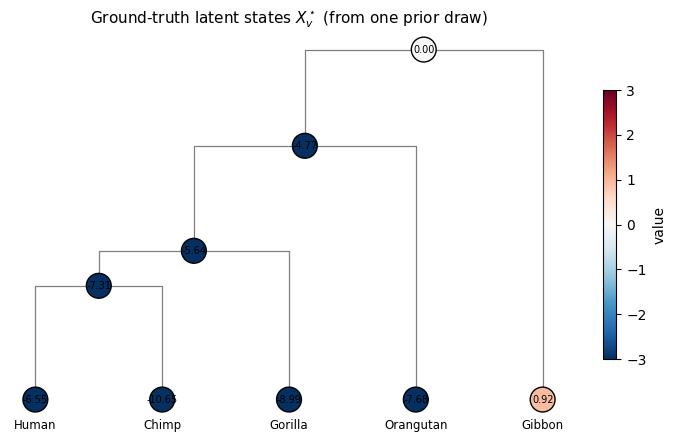

In [4]:
plot_phylo(topo, values=x_truth, edge_lengths=tree.edge_length,
           vmin=-3, vmax=3,
           title='Ground-truth latent states $X_v^\\star$ (from one prior draw)')
plt.show()

## 3. Noisy leaf observations

Pretend the internal states are unobservable. We see only the leaves, corrupted by Gaussian observation noise $\tau^2$:

$$Y_v = X_v^\star + \varepsilon_v, \qquad \varepsilon_v \sim \mathcal{N}(0, \tau^2).$$

`init_gaussian_leaves` turns these observations into the BFFG canonical message at each leaf: $H_v^{\text{leaf}} = I/\tau^2$, $F_v^{\text{leaf}} = H_v^{\text{leaf}} Y_v$, $c_v^{\text{leaf}} = \log\mathcal{N}(Y_v;\,0,\,\tau^2 I)$.

In [5]:
leaf_truth = gt_tree.value[topo.is_leaf]                                # (n_leaves, 1)
obs_noise  = jnp.sqrt(OBS_VAR) * jax.random.normal(key_obs, leaf_truth.shape)
leaf_obs   = leaf_truth + obs_noise

# Initialise leaves with the BFFG canonical (H, F, c) from the noisy observations.
obs_tree = init_gaussian_leaves(tree, leaf_obs, obs_var=OBS_VAR, n=n, d=d)

print(f"{'leaf':<10}  {'truth':>8}  {'obs Y_v':>8}  {'obs - truth':>10}")
leaf_idx = np.where(topo.is_leaf)[0]
for k, i in enumerate(leaf_idx):
    print(f'  {topo.names[i]:<8}  {float(leaf_truth[k, 0]):>8.3f}  {float(leaf_obs[k, 0]):>8.3f}  {float(obs_noise[k, 0]):>10.3f}')

leaf           truth   obs Y_v  obs - truth
  Gibbon       0.919     1.209       0.290
  Orangutan    -7.676    -7.373       0.303
  Gorilla     -8.988    -9.079      -0.092
  Human       -6.549    -6.722      -0.173
  Chimp      -10.648   -10.563       0.085


## 4. Backward filter: `gaussian_up`

We now have the canonical message $(c_v, F_v, H_v)$ at every leaf. The backward filter combines them up the tree, applying the closed-form Gaussian *transition message product* at each edge: if $h_c$ is the message at child $c$ with parameters $(c_c, F_c, H_c)$, then the contribution to the parent's message after pulling through an edge of length $\ell$ with covariance $\ell a$ is

$$
\Phi_c^{-1} = I + \ell\, H_c\, a, \qquad
H_c^{(0)} = \Phi_c^{-1} H_c, \qquad
F_c^{(0)} = \Phi_c^{-1} F_c .
$$

The parent then sums these transformed messages across its children: $H_{\text{pa}} = \sum_c H_c^{(0)}$, $F_{\text{pa}} = \sum_c F_c^{(0)}$. After the up-sweep finishes, the root's $(F_{\text{root}}, H_{\text{root}})$ is the exact Gaussian likelihood of all leaf observations as a function of $X_{\text{root}}$ — and assuming a flat prior on the root, the root's marginal posterior is $\mathcal{N}\bigl(H_{\text{root}}^{-1} F_{\text{root}},\; H_{\text{root}}^{-1}\bigr)$.

In [6]:
up_out = gaussian_up(n, a_fn, d=d)(obs_tree, params=PARAMS)

# Root posterior (flat prior).
F_root = float(up_out.F_T[0, 0])
H_root = float(up_out.H_T[0, 0, 0])
root_post_mean = F_root / H_root
root_post_std  = 1.0 / jnp.sqrt(H_root)

print(f'Root canonical parameters:  F_root = {F_root:.4f},  H_root = {H_root:.4f}')
print(f'Root posterior:              N({root_post_mean:.4f}, {root_post_std:.4f}²)')
print(f'Ground truth root:           X*_root = {float(x_truth[0]):.4f}')
print(f'z-score (truth vs posterior): {abs(float(x_truth[0]) - root_post_mean) / root_post_std:.2f}σ')

Root canonical parameters:  F_root = -0.6790,  H_root = 0.1395
Root posterior:              N(-4.8680, 2.6775²)
Ground truth root:           X*_root = 0.0000
z-score (truth vs posterior): 1.82σ


## 5. Forward guide: posterior samples at every node

The backward sweep gave us, at every node, the canonical message $h_v$. `gaussian_down_conditional` walks the tree top-down and, for each non-root node $v$, samples

$$
X_v \mid X_{\text{pa}(v)},\; h_v \;\sim\; \mathcal{N}(\mu_v,\, \Sigma_v)
$$

where $\mu_v, \Sigma_v$ are the closed-form combination of the parent's just-sampled value and the canonical message — the analogue of the Kalman smoother on a chain. To make this exact at the root we sample $X_{\text{root}}$ from its own marginal posterior $\mathcal{N}\bigl(F/H,\, 1/H\bigr)$ first, then run the down sweep.

Repeating this $N$ times with fresh noise gives $N$ independent draws from the joint posterior. We use `jax.lax.scan` so the entire sampler compiles to a single XLA graph and one trace traces it all.

In [7]:
down_sweep = gaussian_down_conditional(n, a_fn, d=d)

def one_posterior_sample(key):
    k_root, k_noise = jax.random.split(key)
    # 1. Sample root from its analytic posterior.
    eps_root = jax.random.normal(k_root, (1, n * d))
    root_value = root_post_mean + root_post_std * eps_root
    t = up_out.at[topo.is_root].set(value=root_value)
    # 2. Fresh noise on every non-root node.
    t = t.set(noise=jax.random.normal(k_noise, (topo.size, n * d)))
    # 3. Forward guide.
    return down_sweep(t, params=PARAMS).value

def scan_body(_, key):
    return None, one_posterior_sample(key)

N_SAMPLES = 500
sample_keys = jax.random.split(jax.random.PRNGKey(42), N_SAMPLES)
_, samples = jax.lax.scan(scan_body, None, sample_keys)
samples = samples.squeeze(-1)              # shape: (N_SAMPLES, N_nodes)
print(f'Drew {N_SAMPLES} joint posterior samples; shape = {tuple(samples.shape)}')

Drew 500 joint posterior samples; shape = (500, 9)


In [8]:
# Posterior summaries per node.
post_mean = np.asarray(samples.mean(0))
post_std  = np.asarray(samples.std(0))
ci_low    = np.asarray(jnp.percentile(samples, 2.5, axis=0))
ci_high   = np.asarray(jnp.percentile(samples, 97.5, axis=0))
x_truth_np = np.asarray(x_truth)

print(f"{'node':<10}  {'truth':>7}  {'post.mean':>10}  {'post.std':>9}  {'95% CI':>16}  in CI?")
print('-' * 70)
for i in range(topo.size):
    name = topo.names[i] or '(inner)'
    in_ci = ci_low[i] <= x_truth_np[i] <= ci_high[i]
    print(f'  {name:<8}  {x_truth_np[i]:>7.3f}  {post_mean[i]:>10.3f}  {post_std[i]:>9.3f}  '
          f'[{ci_low[i]:>5.2f}, {ci_high[i]:>5.2f}]   {"✓" if in_ci else "✗"}')

node          truth   post.mean   post.std            95% CI  in CI?
----------------------------------------------------------------------
  (inner)     0.000      -4.674      2.710  [-10.10,  0.52]   ✓
  (inner)    -4.774      -6.536      2.169  [-10.69, -2.47]   ✓
  Gibbon      0.919       1.199      0.224  [ 0.77,  1.64]   ✓
  (inner)    -5.640      -8.047      1.703  [-11.22, -4.58]   ✓
  Orangutan   -7.676      -7.363      0.211  [-7.77, -6.96]   ✓
  (inner)    -7.307      -8.305      1.529  [-11.24, -5.20]   ✓
  Gorilla    -8.988      -9.066      0.227  [-9.49, -8.62]   ✓
  Human      -6.549      -6.740      0.228  [-7.16, -6.33]   ✓
  Chimp     -10.648     -10.561      0.227  [-11.03, -10.11]   ✓


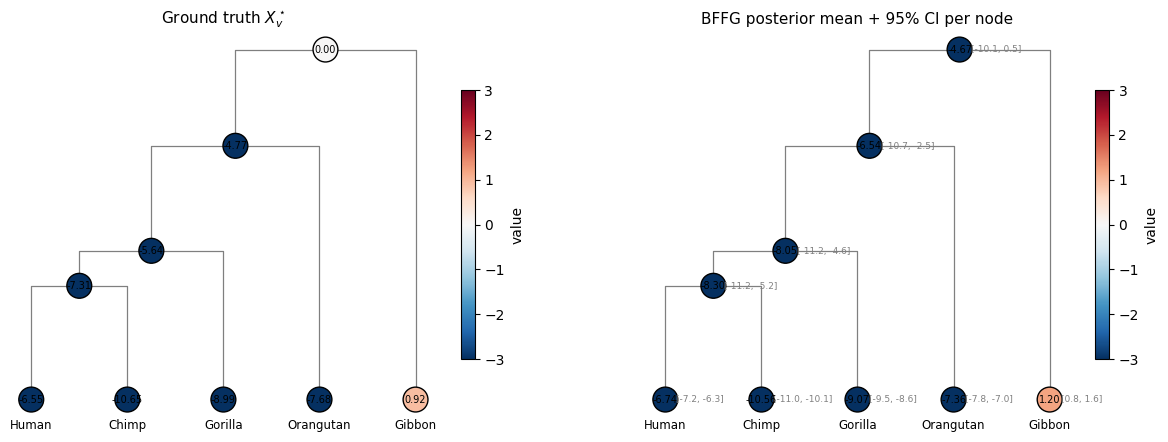

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_phylo(topo, values=x_truth_np, edge_lengths=tree.edge_length,
           ax=axes[0], vmin=-3, vmax=3,
           title='Ground truth $X_v^\\star$')
plot_phylo(topo, values=post_mean, ci_low=ci_low, ci_high=ci_high,
           edge_lengths=tree.edge_length,
           ax=axes[1], vmin=-3, vmax=3,
           title='BFFG posterior mean + 95% CI per node')
plt.show()

What to look for in the plot:

- **Leaves** have very narrow CIs (width ~$2\tau$) — almost all uncertainty came from the observation noise we added.
- **Internal nodes** have wider CIs that grow as you move away from informative leaves. The root in particular collects only fuzzy information about its state because every edge it sees adds $\sigma^2 \ell$ variance to its descendants.
- **The posterior mean tracks the ground truth** within roughly $2\sigma$ at every node — exactly what calibration says we should see.

## 6. BFFG vs `phylo_mean`

How much does the full Bayesian treatment buy us over `phylo_mean`'s point estimate? We can run `phylo_mean` on the exact same observation set and compare per-node estimates. The two are mathematically related — `phylo_mean` is a *limiting case* of BFFG (single-level Gaussian-conjugate update with $\tau^2 \to 0$, see the test suite for the precise statement) — but for a tree with depth, BFFG correctly propagates posterior *precision* through the inner nodes, while `phylo_mean` discards it and treats each level's estimate as a fresh observation.

In [10]:
# Run phylo_mean on the same noisy observations.
pm_tree = hx.Tree.empty(topo, {'estimated_value': (), 'edge_length': ()})
pm_tree = pm_tree.set(edge_length=tree.edge_length)
pm_tree = pm_tree.at[topo.is_leaf].set(estimated_value=leaf_obs.squeeze(-1))
pm_out = phylo_mean()(pm_tree)
pm_mean = np.asarray(pm_out.estimated_value)

print(f"{'node':<10}  {'truth':>7}  {'phylo_mean':>10}  {'BFFG mean':>10}  {'BFFG std':>9}")
print('-' * 60)
for i in range(topo.size):
    name = topo.names[i] or '(inner)'
    print(f'  {name:<8}  {x_truth_np[i]:>7.3f}  {pm_mean[i]:>10.3f}  {post_mean[i]:>10.3f}  {post_std[i]:>9.3f}')

node          truth  phylo_mean   BFFG mean   BFFG std
------------------------------------------------------------
  (inner)     0.000      -6.272      -4.674      2.710
  (inner)    -4.774      -8.330      -6.536      2.169
  Gibbon      0.919       1.209       1.199      0.224
  (inner)    -5.640      -8.726      -8.047      1.703
  Orangutan   -7.676      -7.373      -7.363      0.211
  (inner)    -7.307      -8.642      -8.305      1.529
  Gorilla    -8.988      -9.079      -9.066      0.227
  Human      -6.549      -6.722      -6.740      0.228
  Chimp     -10.648     -10.563     -10.561      0.227


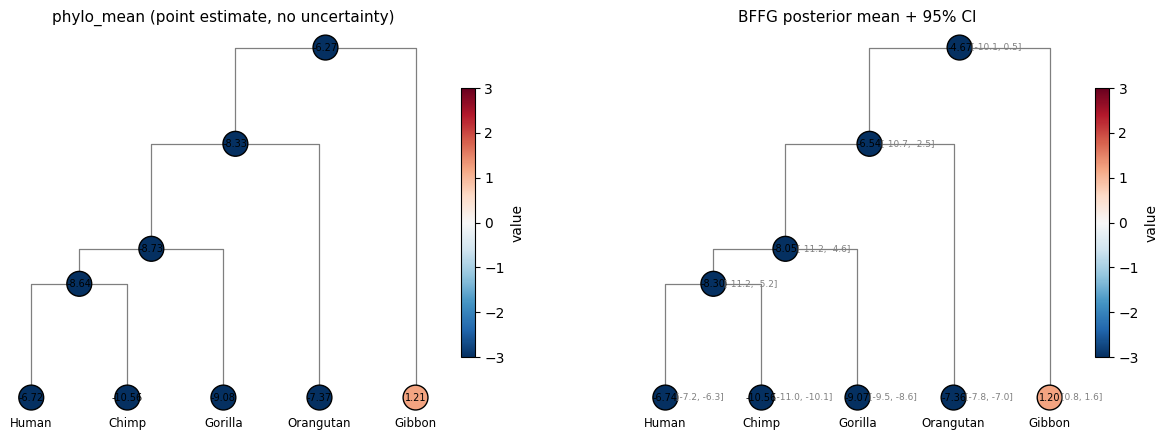

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_phylo(topo, values=pm_mean, edge_lengths=tree.edge_length,
           ax=axes[0], vmin=-3, vmax=3,
           title='phylo_mean (point estimate, no uncertainty)')
plot_phylo(topo, values=post_mean, ci_low=ci_low, ci_high=ci_high,
           edge_lengths=tree.edge_length,
           ax=axes[1], vmin=-3, vmax=3,
           title='BFFG posterior mean + 95% CI')
plt.show()

## 7. A quick coverage check

If the BFFG posterior is correctly calibrated, then over many independent runs the 95% CI at each node should contain the ground truth about 95% of the time. We can probe this cheaply on the *root*, whose marginal posterior we already have in closed form as $\mathcal{N}(F/H,\, 1/H)$: repeat the whole pipeline (forward simulate → noise leaves → backward filter) many times with different seeds, and tally how often the truth falls inside $\hat{\mu}_{\text{root}} \pm 1.96\, \hat\sigma_{\text{root}}$.

In [12]:
@jax.jit
def one_coverage_trial(seed):
    k_root, k_path, k_obs = jax.random.split(jax.random.PRNGKey(seed), 3)
    # Forward simulate ground truth.
    x_root_star = MU_0 + 0.5 * jax.random.normal(k_root, ())  # mild prior
    sim = tree.at[topo.is_root].set(value=jnp.array([[x_root_star]]))
    sim = sim.set(noise=jax.random.normal(k_path, (topo.size, n * d)))
    sim = gaussian_down_unconditional(sigma_fn)(sim, params=PARAMS)
    # Noisy observations.
    leaf_y = sim.value[topo.is_leaf] + jnp.sqrt(OBS_VAR) * jax.random.normal(k_obs, (int(topo.is_leaf.sum()), n * d))
    t = init_gaussian_leaves(tree, leaf_y, obs_var=OBS_VAR, n=n, d=d)
    # Backward filter.
    out = gaussian_up(n, a_fn, d=d)(t, params=PARAMS)
    mu_hat = out.F_T[0, 0] / out.H_T[0, 0, 0]
    sd_hat = 1.0 / jnp.sqrt(out.H_T[0, 0, 0])
    return jnp.abs(x_root_star - mu_hat) < 1.96 * sd_hat

N_TRIALS = 2000
results = jax.vmap(one_coverage_trial)(jnp.arange(N_TRIALS))
coverage = float(results.mean())
print(f'Root 95% CI coverage over {N_TRIALS} trials: {coverage:.3f}')
print('Expected ≈ 0.95 for a well-calibrated Gaussian posterior.')

Root 95% CI coverage over 2000 trials: 0.945
Expected ≈ 0.95 for a well-calibrated Gaussian posterior.


## Recap & next steps

End-to-end workflow you've now seen:

1. Declare the BFFG schema (`c_T`, `F_T`, `H_T`, `value`, `noise`, `logw`) on a tree loaded from Newick.
2. `init_gaussian_leaves` — turn noisy leaf observations into per-leaf canonical messages $(c_v, F_v, H_v)$.
3. `gaussian_up` — closed-form **backward filter** propagates messages leaf → root.
4. `gaussian_down_conditional` — closed-form **forward guide** samples posterior states at every internal node, conditional on its already-sampled parent.
5. Wrap the sampler in `lax.scan` for many parallel posterior draws.
6. Calibrate by repeated forward-simulation: the 95% CI covers truth ≈ 95% of the time.

Compared with `phylo_mean`:

- `phylo_mean` is a *point estimator* — no uncertainty, no model assumptions beyond "closer is more informative."
- The Bayesian / BFFG version is a *full posterior* — exact under a stated linear-Gaussian model, with calibrated CIs at every node.
- On a star-shape tree with $\tau^2 \to 0$ and $\sigma^2 = 1$ they coincide; otherwise the Bayesian estimate is strictly more informative because it propagates posterior precision through every inner node.

Where to go next:

- [**`05_gaussian_bffg.ipynb`**](05_gaussian_bffg.ipynb) — drop the assumption that $(\sigma^2, \tau^2)$ are known. MCMC joint posterior over the latent states *and* the hyperparameters, with BFFG inside the kernel.
- [**`06_gaussian_nuts.ipynb`**](06_gaussian_nuts.ipynb) — same hyperparameter inference, but as **maximum-likelihood point estimation** via gradient-driven MCMC via NUTS, with an ESS comparison against gradient-free RW/pCN.
- [**`07_kunita_shape.ipynb`**](07_kunita_shape.ipynb) — replace linear Gaussian transitions with non-linear SDE bridges. The closed form disappears; BFFG becomes an approximation that MCMC corrects (Crank-Nicolson on the noise field).

### References

**Primary**

- van der Meulen, F. H. & Sommer, S. (2025). *Backward Filtering Forward Guiding.* Journal of Machine Learning Research **26**(281), 1–51. [arXiv:2505.18239](https://arxiv.org/abs/2505.18239) · [JMLR](https://www.jmlr.org/papers/v26/25-1130.html)

**Background & extensions**

- van der Meulen, F. H. & Schauer, M. (2020–2022). *Automatic Backward Filtering Forward Guiding for Markov processes and graphical models.* [arXiv:2010.03509](https://arxiv.org/abs/2010.03509) — earlier general formulation, predecessor to the JMLR paper.
- van der Meulen, F. H. (2022). *Introduction to Automatic Backward Filtering Forward Guiding.* [arXiv:2203.04155](https://arxiv.org/abs/2203.04155) — short introductory note.
- *Neural Backward Filtering Forward Guiding.* [arXiv:2601.23030](https://arxiv.org/abs/2601.23030) — neural-network-parametrized extension (2026).